In [2]:
import pandas as pd

# Load Data

### Daily Data

In [2]:
import pandas as pd
df_daily_data = pd.read_csv('transformed_daily_data/combined_daily_data_with_fbmeta_fix.csv')
df_daily_data

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-05,A,132.09,134.090,131.2500,133.370,1.447574e+06,133.1998,19877.0
1,2021-05-06,A,132.31,132.600,130.7700,132.400,1.173755e+06,131.8933,20455.0
2,2021-05-07,A,133.19,134.820,133.1900,133.900,1.056246e+06,133.9869,17352.0
3,2021-05-10,A,133.76,133.930,131.7600,131.870,1.048008e+06,132.4934,22316.0
4,2021-05-11,A,130.27,131.840,129.3000,131.420,1.356117e+06,131.1175,19161.0
...,...,...,...,...,...,...,...,...,...
4986892,2026-04-27,NaN,2.29,2.290,1.8500,1.850,9.317473e+04,2.1023,1094.0
4986893,2026-04-28,NaN,2.01,2.110,1.7800,1.795,2.693652e+05,1.9115,1846.0
4986894,2026-04-29,NaN,1.86,1.860,1.6000,1.605,1.364121e+05,1.6963,1155.0
4986895,2026-04-30,NaN,1.60,1.850,1.5801,1.770,1.013014e+05,1.6733,858.0


In [3]:
df_daily_data['ticker'].value_counts()

ticker
A       1254
MFA     1254
MEC     1254
MED     1254
MEDP    1254
        ... 
QXL        2
DYNC       1
COAG       1
UCFI       1
SPTX       1
Name: count, Length: 5037, dtype: int64

Filtering

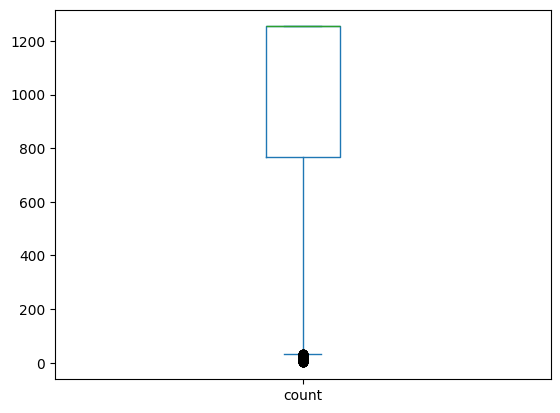

In [4]:
import matplotlib.pyplot as plt

df_daily_data['ticker'].value_counts().plot.box()

plt.show()

In [5]:
thresholds = [1200, 1220, 1229, 1230, 1240, 1250, 1253, 1254]

ticker_counts = df_daily_data['ticker'].value_counts()

for t in thresholds:
    count = (ticker_counts >= t).sum()
    print(f">={t}: {count}")

>=1200: 3145
>=1220: 3068
>=1229: 3033
>=1230: 3025
>=1240: 2985
>=1250: 2924
>=1253: 2870
>=1254: 2804


My original methodology for filling missing days was to find stocks in which no more than 2% of days were missing, AND there were no consecutive missing days, AND none of the missing days were on Monday or Friday. Any remaining missing days would then be forward-filled with the previous day.

This was feasible with a volume filter applied, but since there is none right now, this would be time prohibitive. Therefore, I will tolerate zero missing days. May change this later.

In [6]:
import pandas as pd

ticker_counts = df_daily_data['ticker'].value_counts()

mask = df_daily_data['ticker'].isin(ticker_counts[ticker_counts >= 1254].index)

df_daily_data = df_daily_data[mask]

df_daily_data

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-05,A,132.090,134.090,131.25,133.37,1.447574e+06,133.1998,19877.0
1,2021-05-06,A,132.310,132.600,130.77,132.40,1.173755e+06,131.8933,20455.0
2,2021-05-07,A,133.190,134.820,133.19,133.90,1.056246e+06,133.9869,17352.0
3,2021-05-10,A,133.760,133.930,131.76,131.87,1.048008e+06,132.4934,22316.0
4,2021-05-11,A,130.270,131.840,129.30,131.42,1.356117e+06,131.1175,19161.0
...,...,...,...,...,...,...,...,...,...
4985939,2026-04-27,ZYME,27.930,29.750,27.93,28.56,9.502180e+05,28.8344,13412.0
4985940,2026-04-28,ZYME,28.610,28.885,27.92,27.94,4.214716e+05,28.1324,9773.0
4985941,2026-04-29,ZYME,27.520,27.950,26.77,27.83,8.244088e+05,27.7028,13249.0
4985942,2026-04-30,ZYME,27.975,28.185,27.18,27.54,4.826677e+05,27.5929,11679.0


In [7]:
df_daily_data['ticker'].value_counts()

ticker
A       1254
ONCY    1254
OM      1254
OMC     1254
OMCL    1254
        ... 
FATE    1254
FBIO    1254
FBIZ    1254
FBK     1254
ZYME    1254
Name: count, Length: 2804, dtype: int64

In [8]:
df_daily_data = df_daily_data.sort_values(by=['ticker', 'timestamp'])
df_daily_data

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-05,A,132.090,134.090,131.25,133.37,1.447574e+06,133.1998,19877.0
1,2021-05-06,A,132.310,132.600,130.77,132.40,1.173755e+06,131.8933,20455.0
2,2021-05-07,A,133.190,134.820,133.19,133.90,1.056246e+06,133.9869,17352.0
3,2021-05-10,A,133.760,133.930,131.76,131.87,1.048008e+06,132.4934,22316.0
4,2021-05-11,A,130.270,131.840,129.30,131.42,1.356117e+06,131.1175,19161.0
...,...,...,...,...,...,...,...,...,...
4985939,2026-04-27,ZYME,27.930,29.750,27.93,28.56,9.502180e+05,28.8344,13412.0
4985940,2026-04-28,ZYME,28.610,28.885,27.92,27.94,4.214716e+05,28.1324,9773.0
4985941,2026-04-29,ZYME,27.520,27.950,26.77,27.83,8.244088e+05,27.7028,13249.0
4985942,2026-04-30,ZYME,27.975,28.185,27.18,27.54,4.826677e+05,27.5929,11679.0


Add moving averages - A later question asks for this

In [9]:
df_daily_data['SMA10'] = df_daily_data.groupby('ticker')['close'].transform(lambda x: x.rolling(10).mean())
df_daily_data['SMA20'] = df_daily_data.groupby('ticker')['close'].transform(lambda x: x.rolling(20).mean())
df_daily_data['SMA50'] = df_daily_data.groupby('ticker')['close'].transform(lambda x: x.rolling(50).mean())
df_daily_data['SMA100'] = df_daily_data.groupby('ticker')['close'].transform(lambda x: x.rolling(100).mean())

Add next day and previous day stats here.

In [11]:
df_daily_data['prev_close_pct_change'] = (
    df_daily_data.groupby('ticker')['close']
    .pct_change() * 100
)

df_daily_data['next_close_pct_change'] = (
    (
        df_daily_data.groupby('ticker')['close']
        .shift(-1)
        / df_daily_data['close']
    - 1
    ) * 100
)

In [12]:
df_daily_data

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,SMA10,SMA20,SMA50,SMA100,prev_close_pct_change,next_close_pct_change
0,2021-05-05,A,132.090,134.090,131.25,133.37,1.447574e+06,133.1998,19877.0,NaN,NaN,NaN,NaN,NaN,-0.727300
1,2021-05-06,A,132.310,132.600,130.77,132.40,1.173755e+06,131.8933,20455.0,NaN,NaN,NaN,NaN,-0.727300,1.132931
2,2021-05-07,A,133.190,134.820,133.19,133.90,1.056246e+06,133.9869,17352.0,NaN,NaN,NaN,NaN,1.132931,-1.516057
3,2021-05-10,A,133.760,133.930,131.76,131.87,1.048008e+06,132.4934,22316.0,NaN,NaN,NaN,NaN,-1.516057,-0.341245
4,2021-05-11,A,130.270,131.840,129.30,131.42,1.356117e+06,131.1175,19161.0,NaN,NaN,NaN,NaN,-0.341245,-2.115355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4985939,2026-04-27,ZYME,27.930,29.750,27.93,28.56,9.502180e+05,28.8344,13412.0,27.845,26.8915,25.0433,24.8368,1.637011,-2.170868
4985940,2026-04-28,ZYME,28.610,28.885,27.92,27.94,4.214716e+05,28.1324,9773.0,27.941,27.0780,25.1501,24.8652,-2.170868,-0.393701
4985941,2026-04-29,ZYME,27.520,27.950,26.77,27.83,8.244088e+05,27.7028,13249.0,27.951,27.2175,25.2453,24.8813,-0.393701,-1.042041
4985942,2026-04-30,ZYME,27.975,28.185,27.18,27.54,4.826677e+05,27.5929,11679.0,27.985,27.2975,25.3379,24.8915,-1.042041,-3.376906


In [13]:
df_daily_data = df_daily_data.dropna()

In [14]:
df_daily_data

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,SMA10,SMA20,SMA50,SMA100,prev_close_pct_change,next_close_pct_change
99,2021-09-24,A,172.090,173.080,171.2000,172.40,1.041912e+06,172.4244,15834.0,172.590,174.7785,164.3732,152.4526,-0.214158,-3.491879
100,2021-09-27,A,171.060,171.150,164.2629,166.38,1.419754e+06,166.1472,25590.0,172.020,174.4070,164.7222,152.7827,-3.491879,-3.894699
101,2021-09-28,A,164.190,164.330,158.7900,159.90,2.541015e+06,160.4667,41170.0,170.768,173.5655,164.9686,153.0577,-3.894699,0.062539
102,2021-09-29,A,161.390,161.805,159.8300,160.00,1.268214e+06,160.5194,22512.0,169.389,172.7920,165.1826,153.3187,0.062539,-1.543750
103,2021-09-30,A,161.230,162.480,157.4600,157.53,1.558941e+06,158.5686,21666.0,167.814,171.8960,165.3542,153.5753,-1.543750,-0.977592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4985938,2026-04-24,ZYME,27.510,28.300,26.9300,28.10,5.705914e+05,27.9745,11600.0,27.606,26.6725,24.9355,24.8115,2.442581,1.637011
4985939,2026-04-27,ZYME,27.930,29.750,27.9300,28.56,9.502180e+05,28.8344,13412.0,27.845,26.8915,25.0433,24.8368,1.637011,-2.170868
4985940,2026-04-28,ZYME,28.610,28.885,27.9200,27.94,4.214716e+05,28.1324,9773.0,27.941,27.0780,25.1501,24.8652,-2.170868,-0.393701
4985941,2026-04-29,ZYME,27.520,27.950,26.7700,27.83,8.244088e+05,27.7028,13249.0,27.951,27.2175,25.2453,24.8813,-0.393701,-1.042041


My raw daily dataset ran from 2021/05/05 to 2026/05/01.

When SMAs are applied up to 100 days, the first 99 days will be null as there are insufficient days to calculate SMA100, and consequently will have to be dropped.

Similarly, if next_day metrics are calculated, the final day will have to be dropped as there will be no next day.

With both of these changes, the new span will be 2021/07/15 to 2026/04/30.

### Hourly Data

In [ ]:
df_hourly_data

# EDA TASKS

2. Plot long-term stock data over multiple years.
Create an interactive graph that allows the user to view different time ranges.

This should probably be a Streamlit app then?

3. Start with Apple (AAPL) and plot its stock chart using daily data over several years.

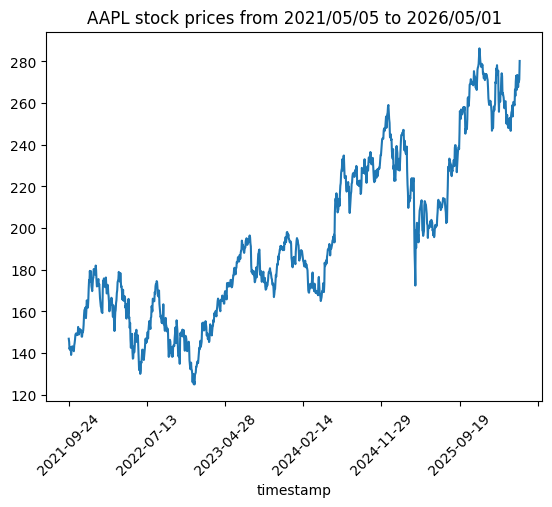

In [13]:
import matplotlib.pyplot as plt

df_aapl = df_daily_data[df_daily_data['ticker'] == 'AAPL']

df_aapl.set_index('timestamp')['close'].plot()
plt.xticks(rotation=45)
# This title will have to be changed if SMA and next_close stats result in rows being dropped
plt.title('AAPL stock prices from 2021/05/05 to 2026/05/01')
plt.show()

4. Add moving averages to the stock charts, such as:
○ SMA20 and SMA50, or
○ SMA50 and SMA150
These should be overlaid on the main stock price chart.

These will have to be added at an earlier stage.

5. Create a table for five stocks. Use default examples such as FAANG stocks plus
NVIDIA, but allow the user to change them.

I'll make the default here for now.

In [27]:
df_daily_data

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,SMA10,SMA20,SMA50,SMA100
99,2021-09-24,A,172.0900,173.0800,171.2000,172.4000,1.041912e+06,172.4244,15834.0,172.59000,174.7785,164.373200,152.452600
1353,2021-09-24,AA,47.8700,49.0800,47.7500,48.4900,5.168089e+06,48.5377,39922.0,48.62000,47.3990,42.783600,40.066600
3378,2021-09-24,AAL,20.8900,21.6200,20.8100,21.3900,3.997169e+07,21.3321,135579.0,20.04200,19.8335,20.106400,21.268000
6203,2021-09-24,AAOI,7.1700,7.3300,7.0800,7.2400,2.427640e+05,7.2296,2403.0,7.19900,7.3880,7.280000,7.704450
7457,2021-09-24,AAON,45.2867,45.3267,44.5733,44.5867,1.620465e+05,44.8386,1724.0,43.90201,44.2260,43.692934,43.214134
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4975044,2026-05-01,ZNTL,4.0000,4.1500,3.9200,4.0900,7.316505e+05,4.0500,8275.0,4.00900,4.2510,3.213100,2.712650
4976810,2026-05-01,ZS,135.3500,140.9900,131.9650,139.8100,2.867503e+06,138.8238,61392.0,136.09400,133.3000,143.659400,177.241350
4979180,2026-05-01,ZTS,116.2200,116.2500,113.7600,114.1600,3.203961e+06,114.5220,47928.0,116.88300,118.2430,119.851800,122.203200
4980434,2026-05-01,ZUMZ,24.5400,25.1700,24.3700,24.3700,1.057050e+05,24.6360,4339.0,24.67300,24.3625,23.687900,24.995150


In [25]:
stock_groups = {
    'all_stocks': df_daily_data['ticker'].unique().tolist(),
    'faanng_stocks': ['AAPL', 'META', 'GOOGL', 'NVDA', 'NFLX', 'AMZN'],
}

stock_groups['non_faanng_stocks'] = [
    x for x in stock_groups['all_stocks']
    if x not in stock_groups['faanng_stocks']
]

df_group_close_avgs = pd.DataFrame({
    col_name: (
        df_daily_data[df_daily_data['ticker'].isin(tickers)]
        .groupby('timestamp')['close']
        .mean()
    )
    for col_name, tickers in stock_groups.items()
}).reset_index()

df_group_close_avgs

,timestamp,all_stocks,faanng_stocks,non_faanng_stocks
0,2021-09-24,1.112251e+07,149.115167,1.114636e+07
1,2021-09-27,1.189703e+07,148.539333,1.192254e+07
2,2021-09-28,1.137996e+07,143.878667,1.140436e+07
3,2021-09-29,1.047585e+07,143.712083,1.049832e+07
4,2021-09-30,1.092804e+07,143.428000,1.095148e+07
...,...,...,...,...
1150,2026-04-27,3.384678e+02,310.945000,3.385268e+02
1151,2026-04-28,3.409392e+02,309.495000,3.410066e+02
1152,2026-04-29,3.386377e+02,308.940000,3.387014e+02
1153,2026-04-30,3.398020e+02,304.383333,3.398779e+02


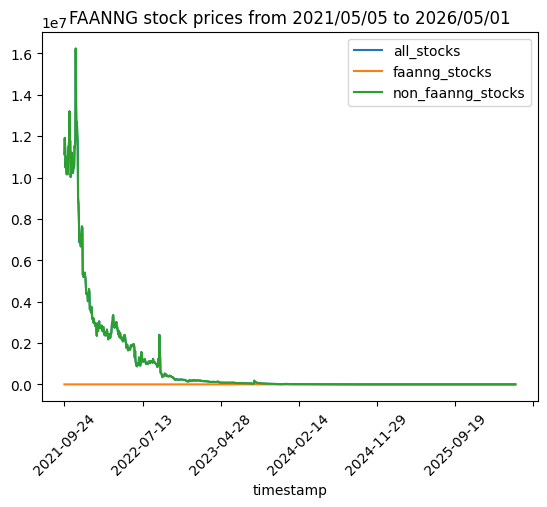

In [26]:
df_group_close_avgs.set_index('timestamp').plot()
plt.xticks(rotation=45)
# This title will have to be changed if SMA and next_close stats result in rows being dropped
plt.title('FAANNG stock prices from 2021/05/05 to 2026/05/01')
plt.show()

# OLD

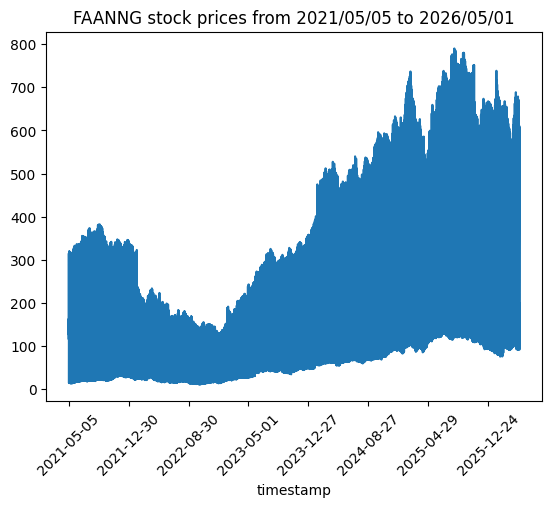

In [61]:
df_faanng.set_index('timestamp')['close'].plot()
plt.xticks(rotation=45)
# This title will have to be changed if SMA and next_close stats result in rows being dropped
plt.title('FAANNG stock prices from 2021/05/05 to 2026/05/01')
plt.show()